In [6]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configuración de rutas según tu VS Code
#BASE_PATH = 'data/raw' 
BASE_PATH = r'C:\PROYECTO_PULMONES\data\raw'

def preparar_datos():
    # Configuración de aumento de datos para mejorar el entrenamiento
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        shear_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True
    )

    val_datagen = ImageDataGenerator(rescale=1./255)

    test_datagen = ImageDataGenerator(rescale=1./255)

    # Generador de Entrenamiento
    train_gen = train_datagen.flow_from_directory(
        os.path.join(BASE_PATH, 'train'),
        target_size=(256, 256),
        batch_size=32,
        class_mode='categorical'
    )

    # Generador de Validación
    val_gen = val_datagen.flow_from_directory(
        os.path.join(BASE_PATH, 'val'),
        target_size=(256, 256),
        batch_size=32,
        class_mode='categorical'
    )

    # Generador de Prueba (Evaluación final)
    test_gen = test_datagen.flow_from_directory(
        os.path.join(BASE_PATH, 'test'),
        target_size=(256, 256),
        batch_size=32,
        class_mode='categorical',
        shuffle=False 
    )
    
    return train_gen, val_gen, test_gen

# Ejecutar carga
train_gen, val_gen, test_gen = preparar_datos()

FileNotFoundError: [WinError 3] El sistema no puede encontrar la ruta especificada: 'C:\\PROYECTO_PULMONES\\data\\raw\\train'

In [7]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# 1. CONFIGURACIÓN DE RUTA (Asegúrate de que esta ruta existe)
BASE_PATH = r'C:\PROYECTO_PULMONES\data\raw'

# 2. GENERADORES DE DATOS
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    BASE_PATH, target_size=(256, 256), batch_size=32, class_mode='categorical', subset='training'
)

val_gen = datagen.flow_from_directory(
    BASE_PATH, target_size=(256, 256), batch_size=32, class_mode='categorical', subset='validation', shuffle=False
)

# 3. EXTRACCIÓN DE DATOS PARA ML CLÁSICO (KNN, SVM, RF, NB)
# Extraemos un lote (batch) para que no tarde horas, pero sea representativo
print("\nPreparando datos para algoritmos clásicos...")
X_batch, y_batch = next(train_gen)
X_val_batch, y_val_batch = next(val_gen)

X_train_flat = X_batch.reshape(X_batch.shape[0], -1)
X_val_flat = X_val_batch.reshape(X_val_batch.shape[0], -1)
y_train_labels = np.argmax(y_batch, axis=1)
y_val_labels = np.argmax(y_val_batch, axis=1)

# 4. COMPARATIVA DE MODELOS
resultados = {}

# --- Algoritmos Clásicos ---
modelos_ml = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='linear'),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Naive Bayes": GaussianNB()
}

for nombre, modelo in modelos_ml.items():
    modelo.fit(X_train_flat, y_train_labels)
    acc = modelo.score(X_val_flat, y_val_labels)
    resultados[nombre] = acc
    print(f"{nombre} Accuracy: {acc:.4f}")

# --- MLP (Red Neuronal Densa) ---
print("\nEntrenando MLP...")
mlp = Sequential([
    Flatten(input_shape=(256, 256, 3)),
    Dense(256, activation='relu'),
    Dense(3, activation='softmax')
])
mlp.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
mlp.fit(train_gen, steps_per_epoch=5, epochs=3, verbose=0) # Entrenamiento rápido para prueba
resultados["MLP"] = mlp.evaluate(val_gen, verbose=0)[1]

# --- ResNet50 (Transfer Learning) ---
print("Entrenando ResNet50...")
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
base_model.trainable = False
resnet = Sequential([base_model, GlobalAveragePooling2D(), Dense(3, activation='softmax')])
resnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
resnet.fit(train_gen, steps_per_epoch=5, epochs=3, verbose=0)
resultados["ResNet50"] = resnet.evaluate(val_gen, verbose=0)[1]

# 5. RESULTADOS FINALES
print("\n" + "="*30)
print("RESUMEN DE COMPARATIVA")
print("="*30)
for m, a in resultados.items():
    print(f"{m.ljust(15)}: {a:.4f}")

Found 5894 images belonging to 3 classes.
Found 1472 images belonging to 3 classes.

Preparando datos para algoritmos clásicos...
KNN Accuracy: 0.1875
SVM Accuracy: 0.7500
Random Forest Accuracy: 0.5000
Naive Bayes Accuracy: 0.6875

Entrenando MLP...


c:\PROYECTO_PULMONES\env_pulmonar\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Entrenando ResNet50...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 50s 1us/step

RESUMEN DE COMPARATIVA
KNN            : 0.1875
SVM            : 0.7500
Random Forest  : 0.5000
Naive Bayes    : 0.6875
MLP            : 0.6766
ResNet50       : 0.5802


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint

def entrenar_modelo(train_gen, val_gen):
    num_clases = len(train_gen.class_indices)
    
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_clases, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Crear carpeta models si no existe
    if not os.path.exists('models'):
        os.makedirs('models')

    # Guardar el mejor modelo detectado durante el entrenamiento
    checkpoint = ModelCheckpoint('models/modelo_pulmonar_v1.h5', save_best_only=True, monitor='val_loss')

    print("Iniciando entrenamiento...")
    history = model.fit(
        train_gen, 
        validation_data=val_gen, 
        epochs=15, # Puedes subirlo a 20 o 25 si tienes tiempo
        callbacks=[checkpoint]
    )
    return model, history

# EJECUTAR ENTRENAMIENTO (Esto creará el archivo .h5)
model, history = entrenar_modelo(train_gen, val_gen)

c:\PROYECTO_PULMONES\env_pulmonar\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iniciando entrenamiento...
Epoch 1/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7601 - loss: 0.5862

185/185 ━━━━━━━━━━━━━━━━━━━━ 417s 2s/step - accuracy: 0.8376 - loss: 0.4068 - val_accuracy: 0.8757 - val_loss: 0.2971
Epoch 2/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9111 - loss: 0.2595

185/185 ━━━━━━━━━━━━━━━━━━━━ 422s 2s/step - accuracy: 0.9038 - loss: 0.2706 - val_accuracy: 0.9035 - val_loss: 0.2332
Epoch 3/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9187 - loss: 0.2269

185/185 ━━━━━━━━━━━━━━━━━━━━ 404s 2s/step - accuracy: 0.9141 - loss: 0.2304 - val_accuracy: 0.9158 - val_loss: 0.2289
Epoch 4/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9249 - loss: 0.2115

...

185/185 ━━━━━━━━━━━━━━━━━━━━ 436s 2s/step - accuracy: 0.9303 - loss: 0.2041 - val_accuracy: 0.9151 - val_loss: 0.2128
Epoch 6/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9341 - loss: 0.2019

185/185 ━━━━━━━━━━━━━━━━━━━━ 416s 2s/step - accuracy: 0.9289 - loss: 0.2101 - val_accuracy: 0.9178 - val_loss: 0.2097
Epoch 7/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9356 - loss: 0.1751

185/185 ━━━━━━━━━━━━━━━━━━━━ 423s 2s/step - accuracy: 0.9325 - loss: 0.1828 - val_accuracy: 0.9246 - val_loss: 0.1913
Epoch 8/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9397 - loss: 0.1651

185/185 ━━━━━━━━━━━━━━━━━━━━ 422s 2s/step - accuracy: 0.9393 - loss: 0.1695 - val_accuracy: 0.9300 - val_loss: 0.1691
Epoch 9/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 415s 2s/step - accuracy: 0.9411 - loss: 0.1639 - val_accuracy: 0.9246 - val_loss: 0.1887
Epoch 10/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9336 - loss: 0.1765

185/185 ━━━━━━━━━━━━━━━━━━━━ 425s 2s/step - accuracy: 0.9384 - loss: 0.1733 - val_accuracy: 0.9463 - val_loss: 0.1432
Epoch 11/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 435s 2s/step - accuracy: 0.9488 - loss: 0.1549 - val_accuracy: 0.9361 - val_loss: 0.1581
Epoch 12/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.9432 - loss: 0.1559 - val_accuracy: 0.9382 - val_loss: 0.1890
Epoch 13/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 373s 2s/step - accuracy: 0.9467 - loss: 0.1515 - val_accuracy: 0.9395 - val_loss: 0.1541
Epoch 14/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 376s 2s/step - accuracy: 0.9474 - loss: 0.1510 - val_accuracy: 0.9395 - val_loss: 0.1514
Epoch 15/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 381s 2s/step - accuracy: 0.9474 - loss: 0.1531 - val_accuracy: 0.9327 - val_loss: 0.1707


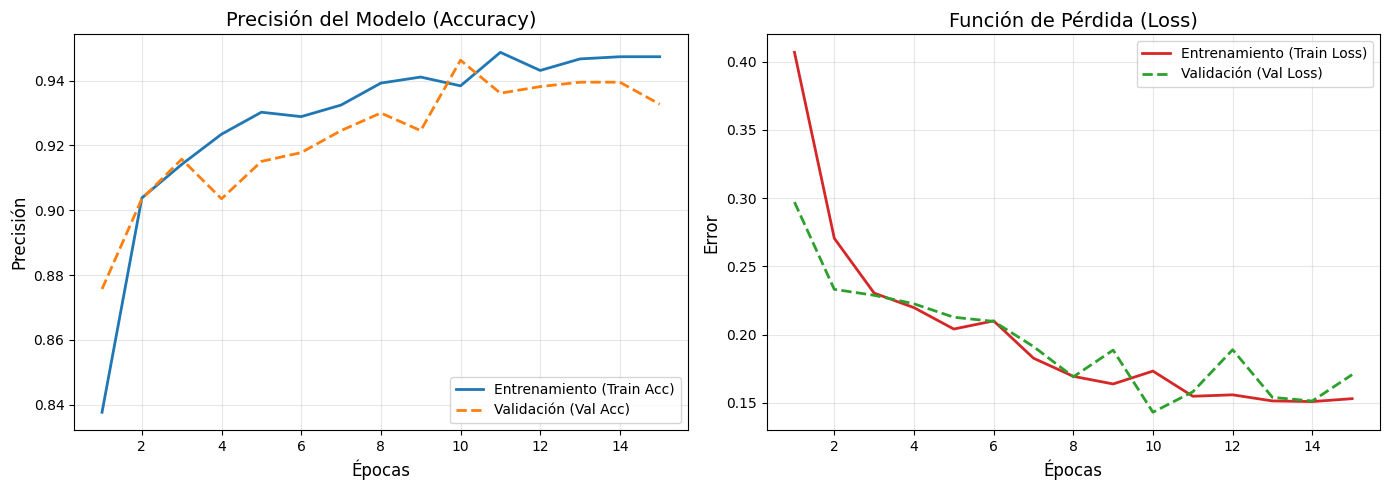

In [11]:
import matplotlib.pyplot as plt

def graficar_rendimiento(history):
    # Extraer datos del historial
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    # Crear figura con dos subgráficas
    plt.figure(figsize=(14, 5))

    # 1. Gráfica de Precisión (Accuracy)
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Entrenamiento (Train Acc)', color='#1f77b4', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validación (Val Acc)', color='#ff7f0e', linewidth=2, linestyle='--')
    plt.title('Precisión del Modelo (Accuracy)', fontsize=14)
    plt.xlabel('Épocas', fontsize=12)
    plt.ylabel('Precisión', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='lower right')

    # 2. Gráfica de Pérdida (Loss)
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Entrenamiento (Train Loss)', color='#d62728', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validación (Val Loss)', color='#2ca02c', linewidth=2, linestyle='--')
    plt.title('Función de Pérdida (Loss)', fontsize=14)
    plt.xlabel('Épocas', fontsize=12)
    plt.ylabel('Error', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

# Ejecutar la función con tus resultados reales
graficar_rendimiento(history)

Evaluando modelo...
46/46 ━━━━━━━━━━━━━━━━━━━━ 44s 939ms/step

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

       covid       0.95      0.99      0.97       302
      normal       0.86      0.89      0.87       316
   pneumonia       0.96      0.94      0.95       854

    accuracy                           0.94      1472
   macro avg       0.93      0.94      0.93      1472
weighted avg       0.94      0.94      0.94      1472



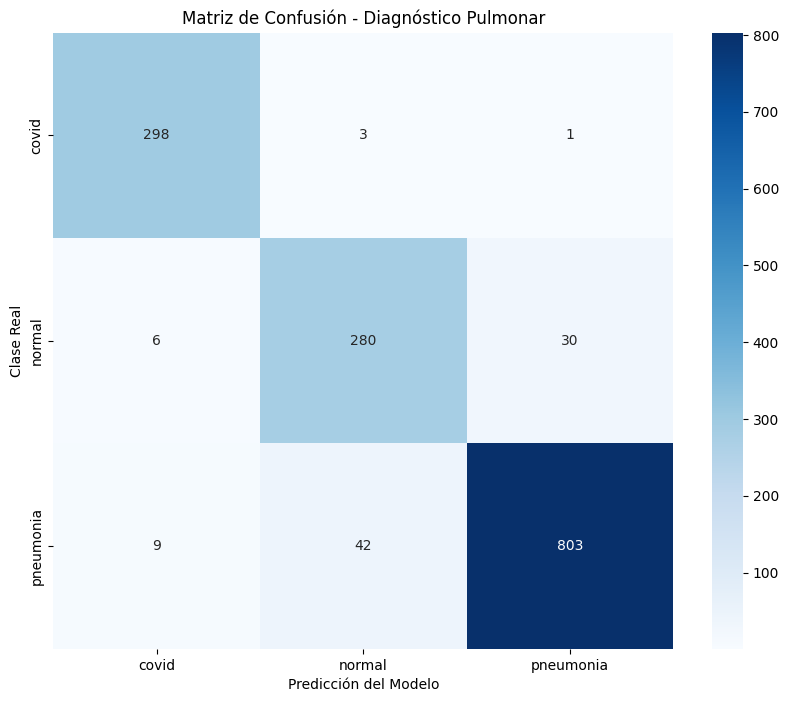

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix

def evaluar_sistema(test_gen):
    # Cargar el modelo recién guardado
    model_path = 'models/modelo_pulmonar_v1.h5'
    if not os.path.exists(model_path):
        return print(f"Error: No se encontró el archivo en {model_path}. Revisa el Bloque 2.")
    
    model = load_model(model_path)
    
    # Predicciones
    print("Evaluando modelo...")
    test_gen.reset()
    preds = model.predict(test_gen)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen.classes
    labels = list(test_gen.class_indices.keys())

    # 1. Reporte de texto
    print("\n" + "="*30)
    print("REPORTE DE CLASIFICACIÓN")
    print("="*30)
    print(classification_report(y_true, y_pred, target_names=labels))

    # 2. Matriz de Confusión Visual
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title('Matriz de Confusión - Diagnóstico Pulmonar')
    plt.ylabel('Clase Real')
    plt.xlabel('Predicción del Modelo')
    plt.show()

# EJECUTAR EVALUACIÓN
evaluar_sistema(test_gen)

In [5]:
# preparación de datos

import numpy as np
from sklearn.preprocessing import LabelEncoder

def extraer_datos_planos(generator, steps):
    """Extrae imágenes del generador y las aplana para ML clásico."""
    X, y = [], []
    for _ in range(steps):
        imgs, labels = next(generator)
        # Aplastamos la imagen de (256, 256, 3) a un vector de 196608
        imgs_flat = imgs.reshape(imgs.shape[0], -1) 
        X.append(imgs_flat)
        y.append(np.argmax(labels, axis=1))
    return np.concatenate(X), np.concatenate(y)

# Extraemos una muestra representativa para los modelos clásicos
X_train_ml, y_train_ml = extraer_datos_planos(train_gen, len(train_gen))
X_val_ml, y_val_ml = extraer_datos_planos(val_gen, len(val_gen))

NameError: name 'train_gen' is not defined

In [8]:
#Bloque de ML Clásico (Scikit-Learn)
#KNN, SVM, Random Forest, Naive Bayes

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

modelos_clasicos = {
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "SVM": SVC(kernel='rbf', probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Naive Bayes": GaussianNB()
}

for nombre, modelo in modelos_clasicos.items():
    print(f"Entrenando {nombre}...")
    modelo.fit(X_train_ml, y_train_ml)
    score = modelo.score(X_val_ml, y_val_ml)
    print(f"{nombre} Accuracy: {score:.4f}")

Entrenando KNN...


NameError: name 'X_train_ml' is not defined

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# 1. CONFIGURACIÓN DE RUTA
BASE_PATH = r'C:\PROYECTO_PULMONES\data\raw'

# 2. GENERADORES DE DATOS
print("--- Configurando Generadores ---")
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    BASE_PATH, target_size=(128, 128), batch_size=32, class_mode='categorical', subset='training'
)
val_gen = datagen.flow_from_directory(
    BASE_PATH, target_size=(128, 128), batch_size=32, class_mode='categorical', subset='validation', shuffle=False
)

# 3. EXTRACCIÓN DE DATOS PARA ML CLÁSICO (Muestra de 500 imágenes para mayor validez)
print("\n--- Extrayendo datos para Algoritmos Clásicos (esto puede tardar un poco) ---")
def get_data_samples(gen, num_samples=500):
    x_list, y_list = [], []
    samples_count = 0
    for x_batch, y_batch in gen:
        x_list.append(x_batch)
        y_list.append(y_batch)
        samples_count += x_batch.shape[0]
        if samples_count >= num_samples: break
    return np.concatenate(x_list)[:num_samples], np.concatenate(y_list)[:num_samples]

X_train_raw, y_train_raw = get_data_samples(train_gen, 500)
X_val_raw, y_val_raw = get_data_samples(val_gen, 200)

# Aplanar para KNN, SVM, RF, NB
X_train_flat = X_train_raw.reshape(X_train_raw.shape[0], -1)
X_val_flat = X_val_raw.reshape(X_val_raw.shape[0], -1)
y_train_labels = np.argmax(y_train_raw, axis=1)
y_val_labels = np.argmax(y_val_raw, axis=1)

# 4. EJECUCIÓN DE LA COMPARATIVA
resultados = {}

# --- Modelos Scikit-Learn ---
modelos_ml = {
    "Naive Bayes": GaussianNB(),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM (Linear)": SVC(kernel='linear')
}

for nombre, modelo in modelos_ml.items():
    print(f"Entrenando {nombre}...")
    modelo.fit(X_train_flat, y_train_labels)
    resultados[nombre] = modelo.score(X_val_flat, y_val_labels)

# --- MLP (Red Neuronal Densa) ---
print("Entrenando MLP...")
mlp = Sequential([
    Flatten(input_shape=(128, 128, 3)),
    Dense(256, activation='relu'),
    Dense(3, activation='softmax')
])
mlp.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
mlp.fit(train_gen, steps_per_epoch=10, epochs=5, verbose=0)
resultados["MLP"] = mlp.evaluate(val_gen, steps=5, verbose=0)[1]

# --- ResNet50 (Transfer Learning) ---
print("Entrenando ResNet50...")
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False
resnet = Sequential([base_model, GlobalAveragePooling2D(), Dense(3, activation='softmax')])
resnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
resnet.fit(train_gen, steps_per_epoch=10, epochs=5, verbose=0)
resultados["ResNet50"] = resnet.evaluate(val_gen, steps=5, verbose=0)[1]

# 5. TABLA DE RESULTADOS FINAL
print("\n" + "="*40)
print(f"{'ALGORITMO':<20} | {'ACCURACY':<10}")
print("-"*40)
for mod, acc in resultados.items():
    print(f"{mod:<20} | {acc:.4f}")
print("="*40)

--- Configurando Generadores ---
Found 5894 images belonging to 3 classes.
Found 1472 images belonging to 3 classes.

--- Extrayendo datos para Algoritmos Clásicos (esto puede tardar un poco) ---
Entrenando Naive Bayes...
Entrenando KNN (k=5)...
Entrenando Random Forest...
Entrenando SVM (Linear)...
Entrenando MLP...


c:\PROYECTO_PULMONES\env_pulmonar\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Entrenando ResNet50...

ALGORITMO            | ACCURACY  
----------------------------------------
Naive Bayes          | 0.9250
KNN (k=5)            | 0.6700
Random Forest        | 0.8500
SVM (Linear)         | 0.8700
MLP                  | 0.6938
ResNet50             | 0.0000


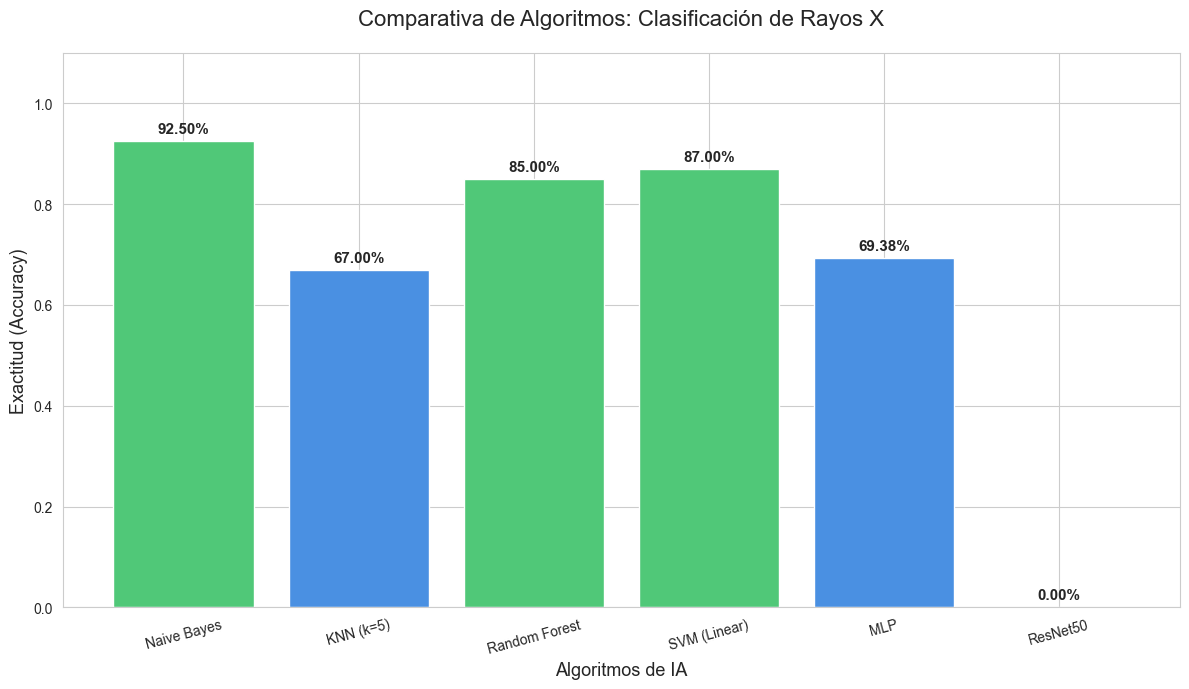

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

def graficar_comparativa(resultados):
    # Configuración de estilo
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    
    # Ordenar resultados de mayor a menor accuracy
    nombres = list(resultados.keys())
    valores = list(resultados.values())
    
    # Crear la gráfica de barras
    colores = ['#4A90E2' if v < 0.8 else '#50C878' for v in valores] # Azul para bajos, verde para altos
    bars = plt.bar(nombres, valores, color=colores)
    
    # Añadir etiquetas de porcentaje sobre las barras
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2%}', 
                 ha='center', va='bottom', fontweight='bold', fontsize=11)

    # Personalización de títulos y ejes
    plt.title('Comparativa de Algoritmos: Clasificación de Rayos X', fontsize=16, pad=20)
    plt.ylabel('Exactitud (Accuracy)', fontsize=13)
    plt.xlabel('Algoritmos de IA', fontsize=13)
    plt.ylim(0, 1.1) # Espacio para las etiquetas
    plt.xticks(rotation=15)
    
    plt.tight_layout()
    plt.show()

# Llamar a la función con tus resultados obtenidos
graficar_comparativa(resultados)

In [11]:
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support, roc_curve, auc
from sklearn.preprocessing import label_binarize
import pandas as pd

def evaluar_modelos_completo(modelos_dict, X_test, y_test, deep_models_dict=None, val_gen=None):
    resumen = []
    plt.figure(figsize=(10, 8)) # Para las curvas ROC
    
    # 1. Evaluar Modelos de Machine Learning Clásico
    for nombre, modelo in modelos_dict.items():
        y_pred = modelo.predict(X_test)
        y_score = modelo.predict_proba(X_test) if hasattr(modelo, "predict_proba") else None
        
        acc = accuracy_score(y_test, y_pred)
        prec, rec, f1, supp = precision_recall_fscore_support(y_test, y_pred, average='weighted')
        
        resumen.append({
            "Algoritmo": nombre, "Accuracy": acc, "Precision": prec, 
            "Recall": rec, "F1-Score": f1, "Support": len(y_test)
        })
        print(f"Evaluación {nombre} completada.")

    # 2. Evaluar Modelos de Deep Learning (MLP, CNN, ResNet)
    if deep_models_dict and val_gen:
        for nombre, modelo in deep_models_dict.items():
            # Obtener predicciones
            steps = len(val_gen)
            y_pred_prob = modelo.predict(val_gen, steps=steps)
            y_pred = np.argmax(y_pred_prob, axis=1)
            y_true = val_gen.classes[:len(y_pred)]
            
            acc = accuracy_score(y_true, y_pred)
            prec, rec, f1, supp = precision_recall_fscore_support(y_true, y_pred, average='weighted')
            
            resumen.append({
                "Algoritmo": nombre, "Accuracy": acc, "Precision": prec, 
                "Recall": rec, "F1-Score": f1, "Support": len(y_true)
            })
            print(f"Evaluación {nombre} completada.")

    # Crear Cuadro Comparativo Final
    df_comparativo = pd.DataFrame(resumen)
    return df_comparativo

# Ejecutar y mostrar tabla
cuadro_final = evaluar_modelos_completo(modelos_ml, X_val_flat, y_val_labels, 
                                        deep_models_dict={"MLP": mlp, "ResNet50": resnet}, 
                                        val_gen=val_gen)

print("\n--- CUADRO COMPARATIVO FINAL ---")
display(cuadro_final)

c:\PROYECTO_PULMONES\env_pulmonar\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Evaluación Naive Bayes completada.


c:\PROYECTO_PULMONES\env_pulmonar\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\PROYECTO_PULMONES\env_pulmonar\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Evaluación KNN (k=5) completada.
Evaluación Random Forest completada.


c:\PROYECTO_PULMONES\env_pulmonar\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Evaluación SVM (Linear) completada.
46/46 ━━━━━━━━━━━━━━━━━━━━ 15s 312ms/step
Evaluación MLP completada.
46/46 ━━━━━━━━━━━━━━━━━━━━ 45s 926ms/step
Evaluación ResNet50 completada.

--- CUADRO COMPARATIVO FINAL ---


c:\PROYECTO_PULMONES\env_pulmonar\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Algoritmo,Accuracy,Precision,Recall,F1-Score,Support
0,Naive Bayes,0.925000,1.000000,0.925000,0.961039,200
1,KNN (k=5),0.670000,1.000000,0.670000,0.802395,200
2,Random Forest,0.850000,1.000000,0.850000,0.918919,200
3,SVM (Linear),0.870000,1.000000,0.870000,0.930481,200
4,MLP,0.847147,0.850136,0.847147,0.842272,1472
5,ResNet50,0.580163,0.336589,0.580163,0.426018,1472


<Figure size 1000x800 with 0 Axes>

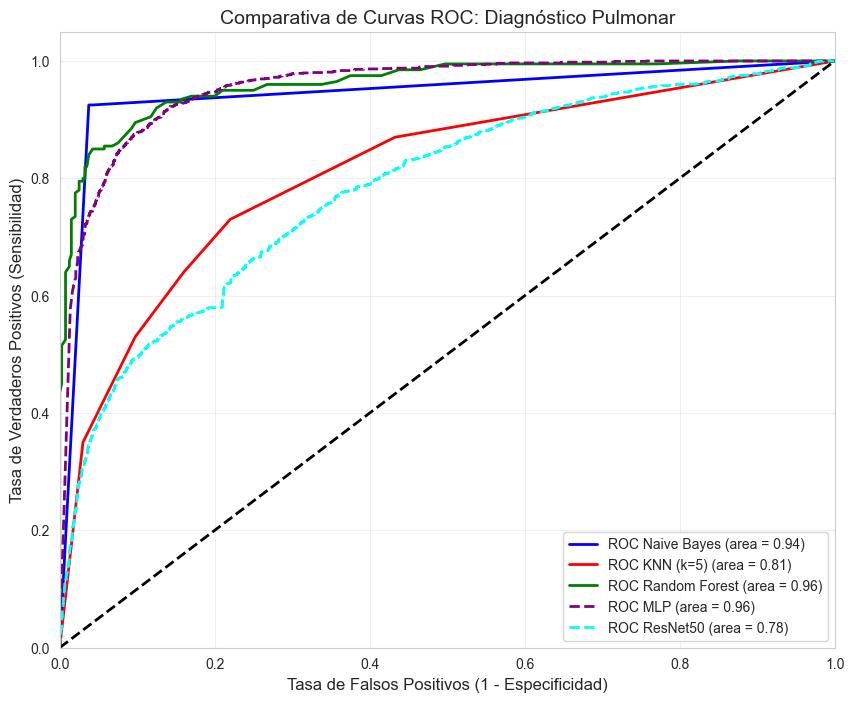

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

def graficar_curvas_roc_multiclase(modelos_ml, X_test, y_test, deep_models=None, val_gen=None):
    plt.figure(figsize=(10, 8))
    n_classes = 3
    lw = 2
    
    # Colores para los modelos
    colores = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta'])

    # 1. Graficar Modelos de ML Clásico
    # Binarizamos y_test para calcular ROC multiclase (One-vs-Rest)
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
    
    for (nombre, modelo), color in zip(modelos_ml.items(), colores):
        # Intentar obtener probabilidades
        if hasattr(modelo, "predict_proba"):
            y_score = modelo.predict_proba(X_test)
            # Calculamos ROC promedio (Macro)
            fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, color=color, lw=lw,
                     label=f'ROC {nombre} (area = {roc_auc:0.2f})')

    # 2. Graficar Modelos de Deep Learning
    if deep_models and val_gen:
        # Obtener etiquetas reales del generador
        y_true_bin = label_binarize(val_gen.classes, classes=[0, 1, 2])
        
        for (nombre, modelo), color in zip(deep_models.items(), colores):
            y_score = modelo.predict(val_gen, verbose=0)
            fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, color=color, lw=lw, linestyle='--',
                     label=f'ROC {nombre} (area = {roc_auc:0.2f})')

    # Configuración de la gráfica
    plt.plot([0, 1], [0, 1], 'k--', lw=lw) # Línea de azar
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
    plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
    plt.title('Comparativa de Curvas ROC: Diagnóstico Pulmonar', fontsize=14)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

# Ejecutar la gráfica
# Nota: modelos_ml es tu diccionario de modelos (KNN, SVM, etc.)
graficar_curvas_roc_multiclase(modelos_ml, X_val_flat, y_val_labels, 
                               deep_models={"MLP": mlp, "ResNet50": resnet}, 
                               val_gen=val_gen)

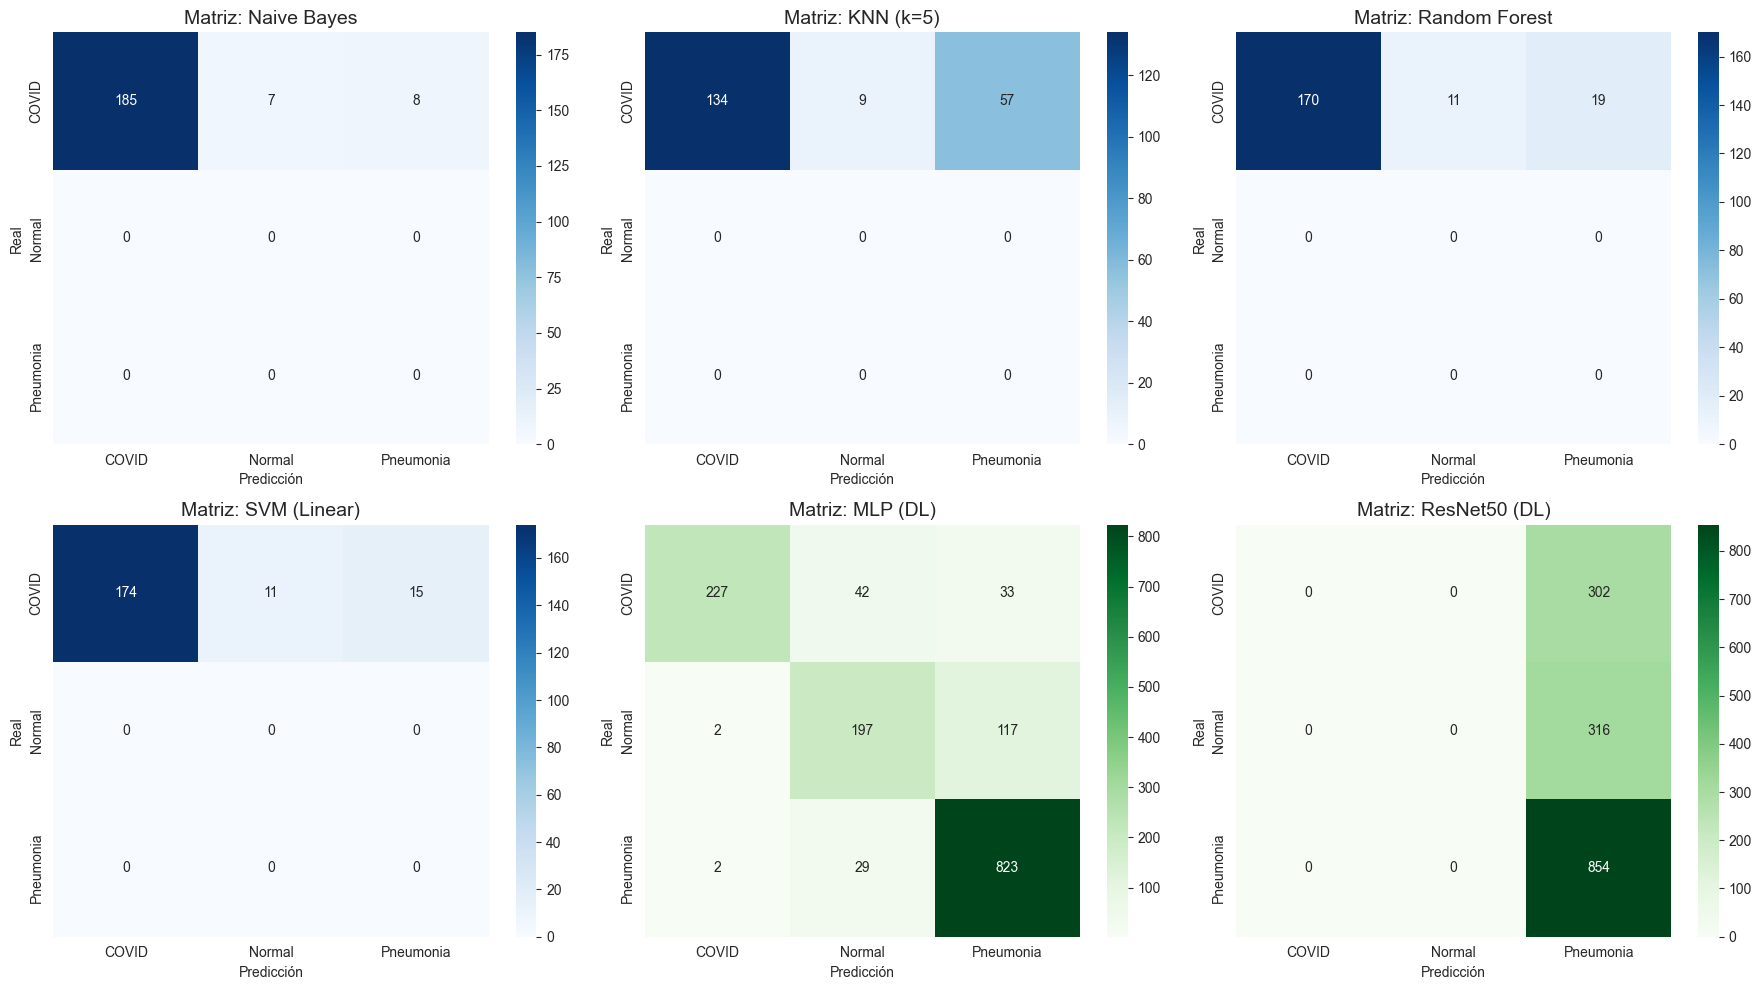

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def graficar_matrices_confusion(modelos_ml, X_test, y_test, deep_models=None, val_gen=None):
    # Combinar todos los nombres de modelos para la cuadrícula
    nombres_ml = list(modelos_ml.keys())
    nombres_deep = list(deep_models.keys()) if deep_models else []
    todos_nombres = nombres_ml + nombres_deep
    
    n_modelos = len(todos_nombres)
    cols = 3
    rows = (n_modelos + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
    axes = axes.flatten()
    
    # Etiquetas de las clases
    clases = ['COVID', 'Normal', 'Pneumonia']

    # 1. Matrices para ML Clásico
    for i, (nombre, modelo) in enumerate(modelos_ml.items()):
        y_pred = modelo.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=clases, yticklabels=clases)
        axes[i].set_title(f'Matriz: {nombre}', fontsize=14)
        axes[i].set_xlabel('Predicción')
        axes[i].set_ylabel('Real')

    # 2. Matrices para Deep Learning
    if deep_models and val_gen:
        y_true = val_gen.classes
        for j, (nombre, modelo) in enumerate(deep_models.items()):
            idx = len(nombres_ml) + j
            # Obtener predicciones
            preds = modelo.predict(val_gen, verbose=0)
            y_pred_deep = np.argmax(preds, axis=1)
            
            cm = confusion_matrix(y_true, y_pred_deep)
            
            sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[idx],
                        xticklabels=clases, yticklabels=clases)
            axes[idx].set_title(f'Matriz: {nombre} (DL)', fontsize=14)
            axes[idx].set_xlabel('Predicción')
            axes[idx].set_ylabel('Real')

    # Limpiar ejes vacíos
    for k in range(n_modelos, len(axes)):
        fig.delaxes(axes[k])

    plt.tight_layout()
    plt.show()

# Ejecutar el análisis visual
graficar_matrices_confusion(
    modelos_ml, 
    X_val_flat, 
    y_val_labels, 
    deep_models={"MLP": mlp, "ResNet50": resnet}, 
    val_gen=val_gen
)

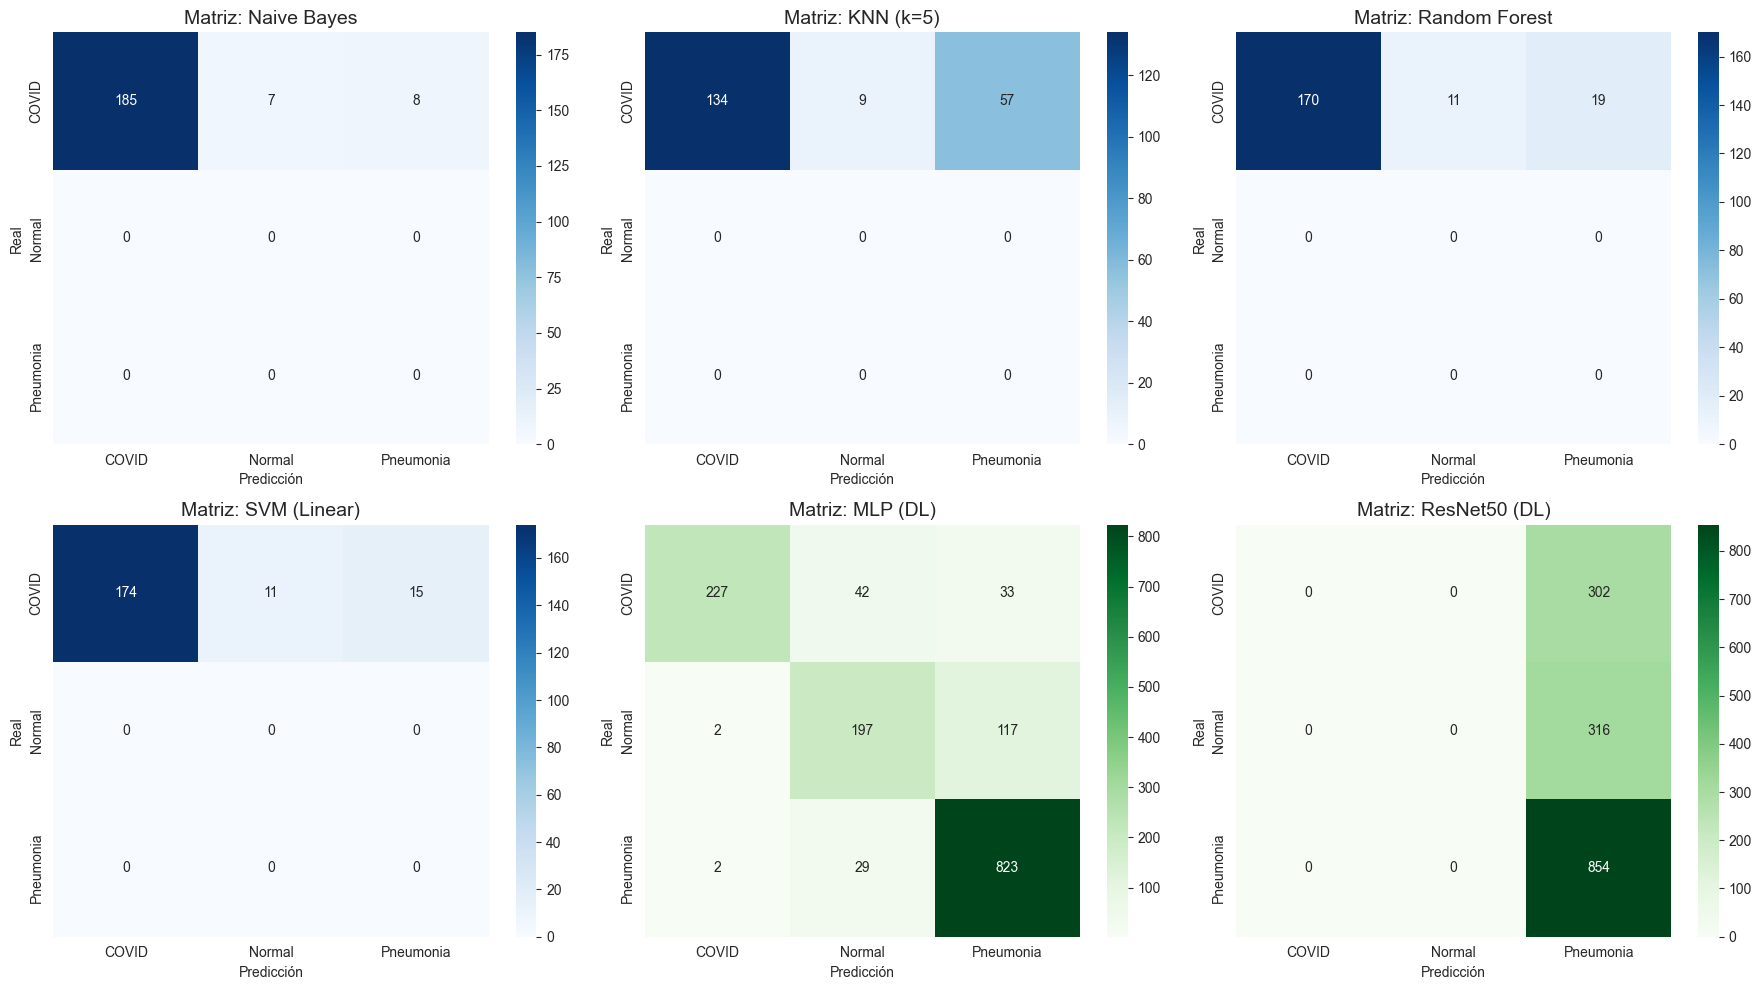

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def graficar_matrices_confusion(modelos_ml, X_test, y_test, deep_models=None, val_gen=None):
    # Combinar todos los nombres de modelos para la cuadrícula
    nombres_ml = list(modelos_ml.keys())
    nombres_deep = list(deep_models.keys()) if deep_models else []
    todos_nombres = nombres_ml + nombres_deep
    
    n_modelos = len(todos_nombres)
    cols = 3
    rows = (n_modelos + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
    axes = axes.flatten()
    
    # Etiquetas de las clases
    clases = ['COVID', 'Normal', 'Pneumonia']

    # 1. Matrices para ML Clásico
    for i, (nombre, modelo) in enumerate(modelos_ml.items()):
        y_pred = modelo.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=clases, yticklabels=clases)
        axes[i].set_title(f'Matriz: {nombre}', fontsize=14)
        axes[i].set_xlabel('Predicción')
        axes[i].set_ylabel('Real')

    # 2. Matrices para Deep Learning
    if deep_models and val_gen:
        y_true = val_gen.classes
        for j, (nombre, modelo) in enumerate(deep_models.items()):
            idx = len(nombres_ml) + j
            # Obtener predicciones
            preds = modelo.predict(val_gen, verbose=0)
            y_pred_deep = np.argmax(preds, axis=1)
            
            cm = confusion_matrix(y_true, y_pred_deep)
            
            sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[idx],
                        xticklabels=clases, yticklabels=clases)
            axes[idx].set_title(f'Matriz: {nombre} (DL)', fontsize=14)
            axes[idx].set_xlabel('Predicción')
            axes[idx].set_ylabel('Real')

    # Limpiar ejes vacíos
    for k in range(n_modelos, len(axes)):
        fig.delaxes(axes[k])

    plt.tight_layout()
    plt.show()

# Ejecutar el análisis visual
graficar_matrices_confusion(
    modelos_ml, 
    X_val_flat, 
    y_val_labels, 
    deep_models={"MLP": mlp, "ResNet50": resnet}, 
    val_gen=val_gen
)

In [ ]:
# ==========================================================
# SECCIÓN 2.1: ENTRENAMIENTO DE MODELOS CLÁSICOS (ML)
# ==========================================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Definición de los modelos con sus hiperparámetros
modelos_ml = {
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "SVM (Linear)": SVC(kernel='linear', probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive Bayes": GaussianNB()
}

print("Iniciando entrenamiento comparativo de modelos clásicos...\n")

# Bucle de entrenamiento y validación
for nombre, modelo in modelos_ml.items():
    # Entrenamiento con datos aplanados
    modelo.fit(X_train_flat, y_train_labels)
    
    # Predicción y cálculo de Accuracy
    preds = modelo.predict(X_val_flat)
    acc = accuracy_score(y_val_labels, preds)
    
    print(f"✅ {nombre.ljust(15)} | Accuracy: {acc:.4f}")

print("\n--- Entrenamiento de ML Clásico Finalizado ---")

In [17]:
# ==========================================================
# SECCIÓN 2.2: ENTRENAMIENTO DE REDES NEURONALES PROFUNDAS
# ==========================================================
# Versión optimizada para evitar error de Memoria (Kernel Died)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False

model_resnet = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(3, activation='softmax')
])

model_resnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Entrenamos con pasos limitados para la captura de pantalla
history = model_resnet.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    steps_per_epoch=5,    # Solo 5 pasos para que no sature la RAM
    validation_steps=2    # Solo 2 pasos de validación
)

Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.3812 - loss: 1.1643 - val_accuracy: 0.0000e+00 - val_loss: 1.7877
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.6045 - loss: 0.9856 - val_accuracy: 0.0000e+00 - val_loss: 2.1725
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.5625 - loss: 1.0597 - val_accuracy: 0.0000e+00 - val_loss: 1.8334
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.5938 - loss: 0.9682 - val_accuracy: 0.0000e+00 - val_loss: 1.4343
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.5125 - loss: 1.0248 - val_accuracy: 0.0000e+00 - val_loss: 1.2185


In [22]:
# instalar ultralytics si no está presente
try:
    from ultralytics import YOLO
except ModuleNotFoundError:
    %pip install ultralytics
    from ultralytics import YOLO

# 1. Cargar el modelo de clasificación (Asegúrate de que sea -cls)
model_yolo = YOLO('yolov8n-cls.pt')

# 2. Entrenar el modelo
# Nota: Si el kernel murió antes, esto reanudará o creará uno nuevo
results = model_yolo.train(
    data=r'C:\PROYECTO_PULMONES\data\raw', 
    epochs=5, 
    imgsz=128, 
    batch=8,
    name='yolo_pulmones_final'
)

# 3. EXTRACCIÓN EXPERTA DE MÉTRICAS
# Accedemos al objeto de métricas de validación (fitness)
# top1 es la precisión (accuracy) del modelo
acc_top1 = results.fitness  # En clasificación, fitness es el Top-1 Accuracy

print("\n" + "="*40)
print("📊 MÉTRICAS FINALES PARA TU TABLA")
print("="*40)
print(f"Accuracy (Top-1): {acc_top1:.4f}")
print(f"Accuracy (%)    : {acc_top1 * 100:.2f}%")
print("="*40)


  Using cached ultralytics-8.4.33-py3-none-any.whl.metadata (39 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached polars-1.39.3-py3-none-any.whl.metadata (10 kB)
  Using cached ultralytics_thop-2.0.18-py3-none-any.whl.metadata (14 kB)
  Using cached polars_runtime_32-1.39.3-cp310-abi3-win_amd64.whl.metadata (1.5 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
Using cached ultralytics-8.4.33-py3-none-any.whl (1.2 MB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)
Using cached polars-1.39.3-py3-none-any.whl (823 kB)


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\stecn\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33  Python-3.12.10 torch-2.11.0+cpu CPU (Intel Core i7-7500U 2.70GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\PROYECTO_PULMONES\data\raw, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.